In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
clstdnt_data = pd.read_csv('../data/dataset.csv', sep=',')
clstdnt_data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print(clstdnt_data.info())
print("DATAFRAME SHAPE \n", clstdnt_data.shape)

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

In [4]:
print("CHECKING NULL OR MISSING VALUES \n", clstdnt_data.isnull().sum())
print("CHECKING DUPLICATED ROWS:", clstdnt_data.duplicated().sum())

CHECKING NULL OR MISSING VALUES 
 Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                 

### **SHOWING THE DISTRIBUTION OF THE SEVERAL FEATURES**

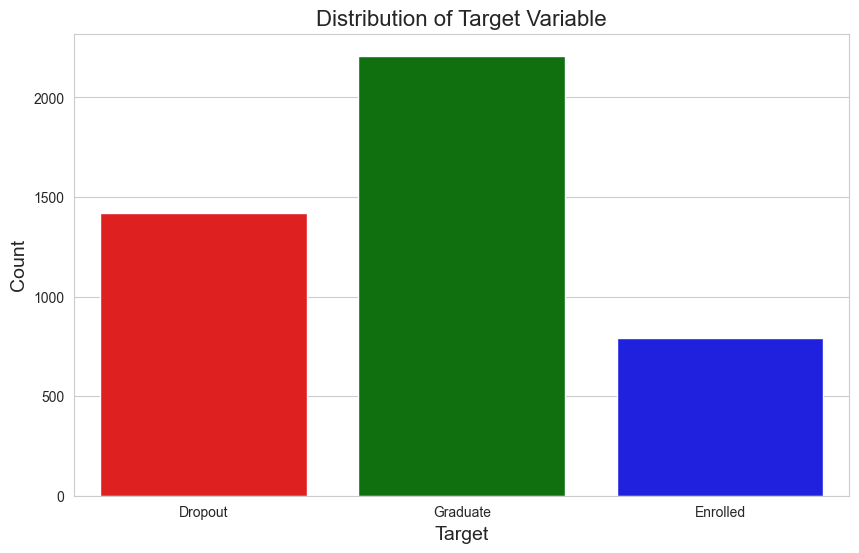

In [5]:
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.countplot(data = clstdnt_data, x = 'Target', palette = ['red', 'green', "blue"])
plt.title('Distribution of Target Variable', fontsize=16)
plt.xlabel('Target', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

**Description:**
- ***Dropout***: A student who leaves university before completing their degree.

- ***Enrolled***: A student who is still actively registered and currently continuing their studies (ongoing status).

- ***Graduate***: A student who has completed all academic requirements and has officially graduated.

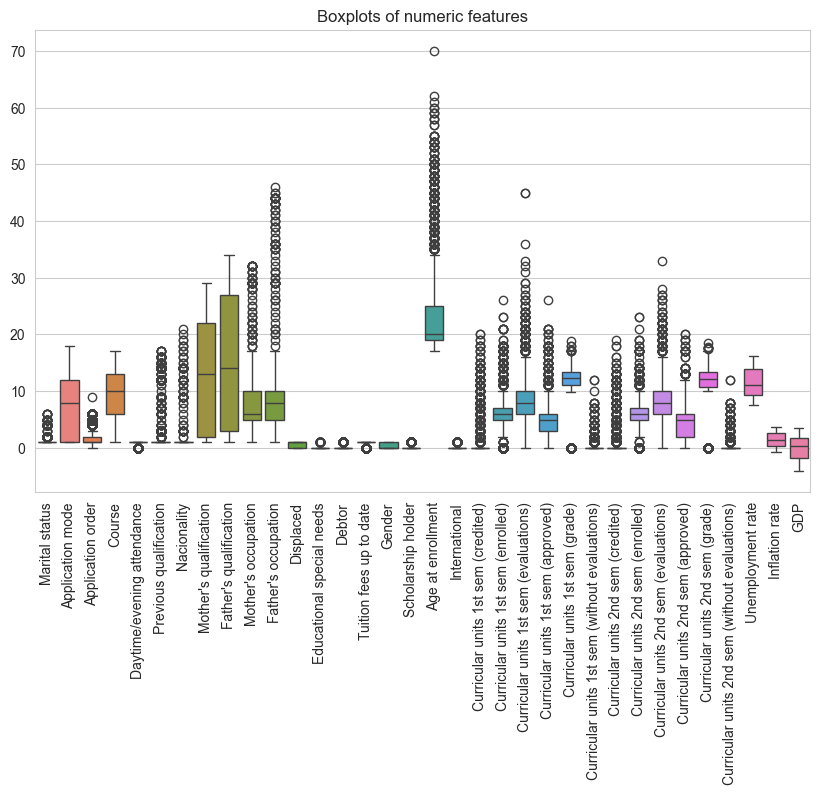

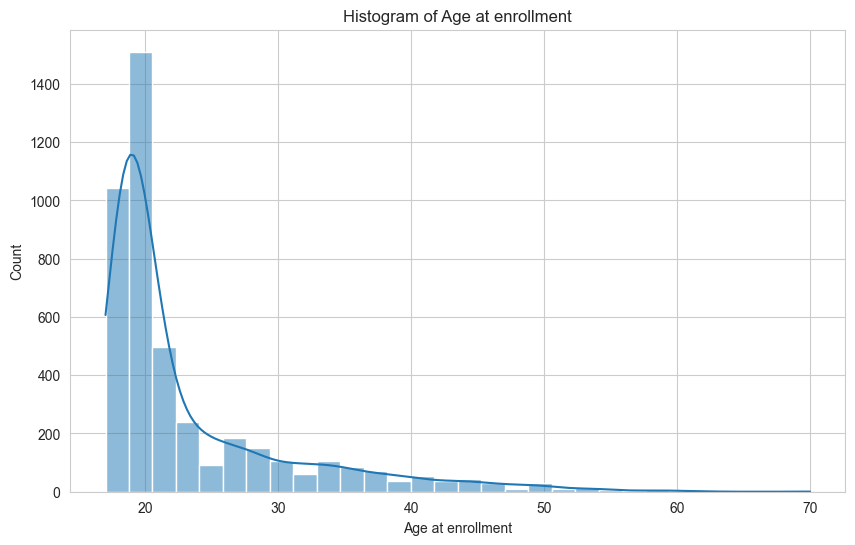

In [6]:
# Boxplot to spot outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=clstdnt_data.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title('Boxplots of numeric features')
plt.show()

# Histogram for a specific feature (example: Age at enrollment)
plt.figure(figsize=(10, 6))
sns.histplot(clstdnt_data['Age at enrollment'], bins=30, kde=True)
plt.title('Histogram of Age at enrollment')
plt.show()

### **ANALYS THE TOP 10 FEATURES CORRELATION**

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = clstdnt_data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    clstdnt_data[col] = le.fit_transform(clstdnt_data[col])

numeric_cols = clstdnt_data.select_dtypes(include=[np.number]).columns
correlation = clstdnt_data[numeric_cols].corr()['Target'].sort_values(ascending=False)
print("Top 10 Features with highest correlation to Target:")
print(correlation.head(10))

Top 10 Features with highest correlation to Target:
Target                                 1.000000
Curricular units 2nd sem (approved)    0.624157
Curricular units 2nd sem (grade)       0.566827
Curricular units 1st sem (approved)    0.529123
Curricular units 1st sem (grade)       0.485207
Tuition fees up to date                0.409827
Scholarship holder                     0.297595
Curricular units 2nd sem (enrolled)    0.175847
Curricular units 1st sem (enrolled)    0.155974
Displaced                              0.113986
Name: Target, dtype: float64


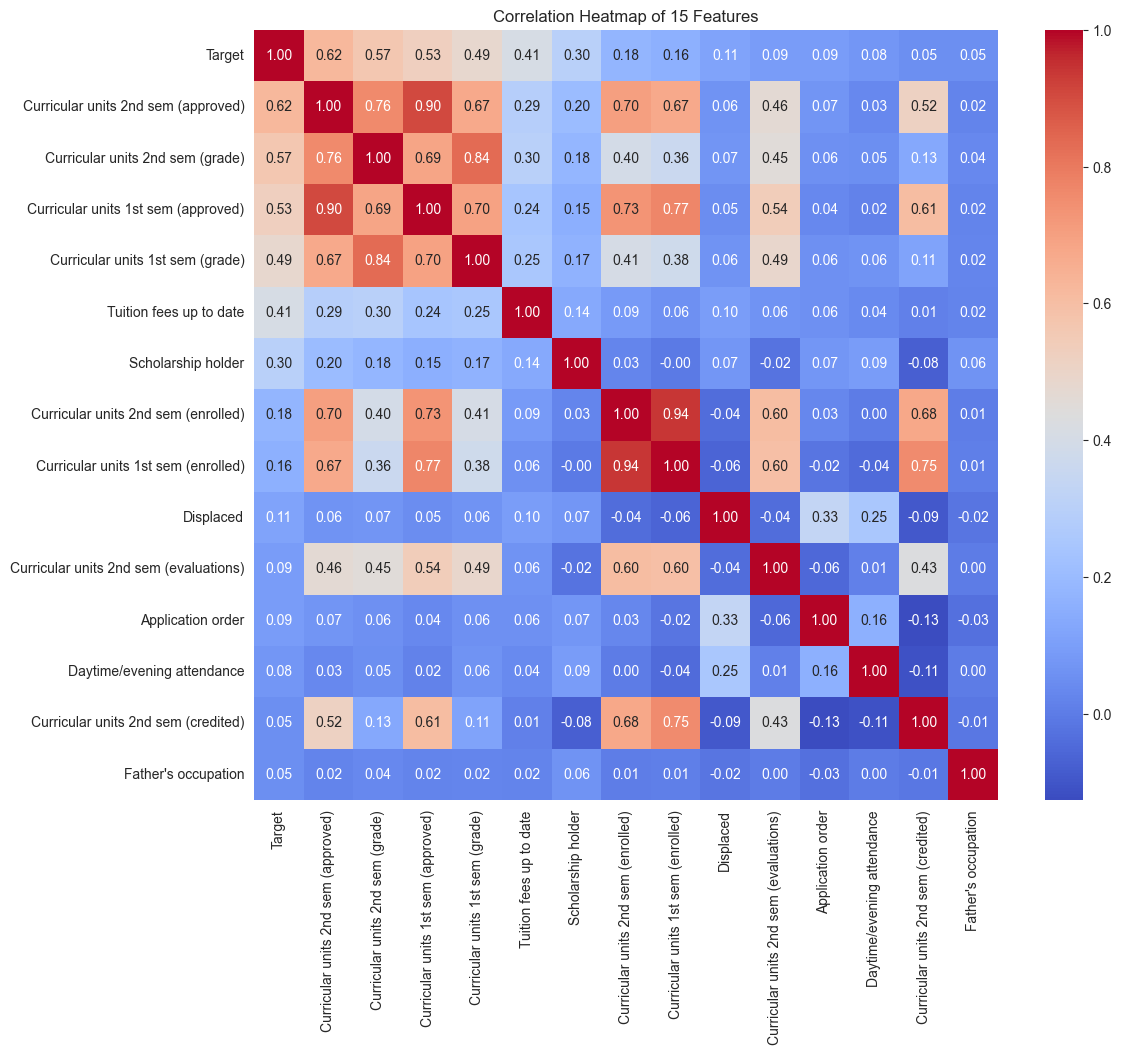

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(clstdnt_data[correlation.head(15).index].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of 15 Features')
plt.show()

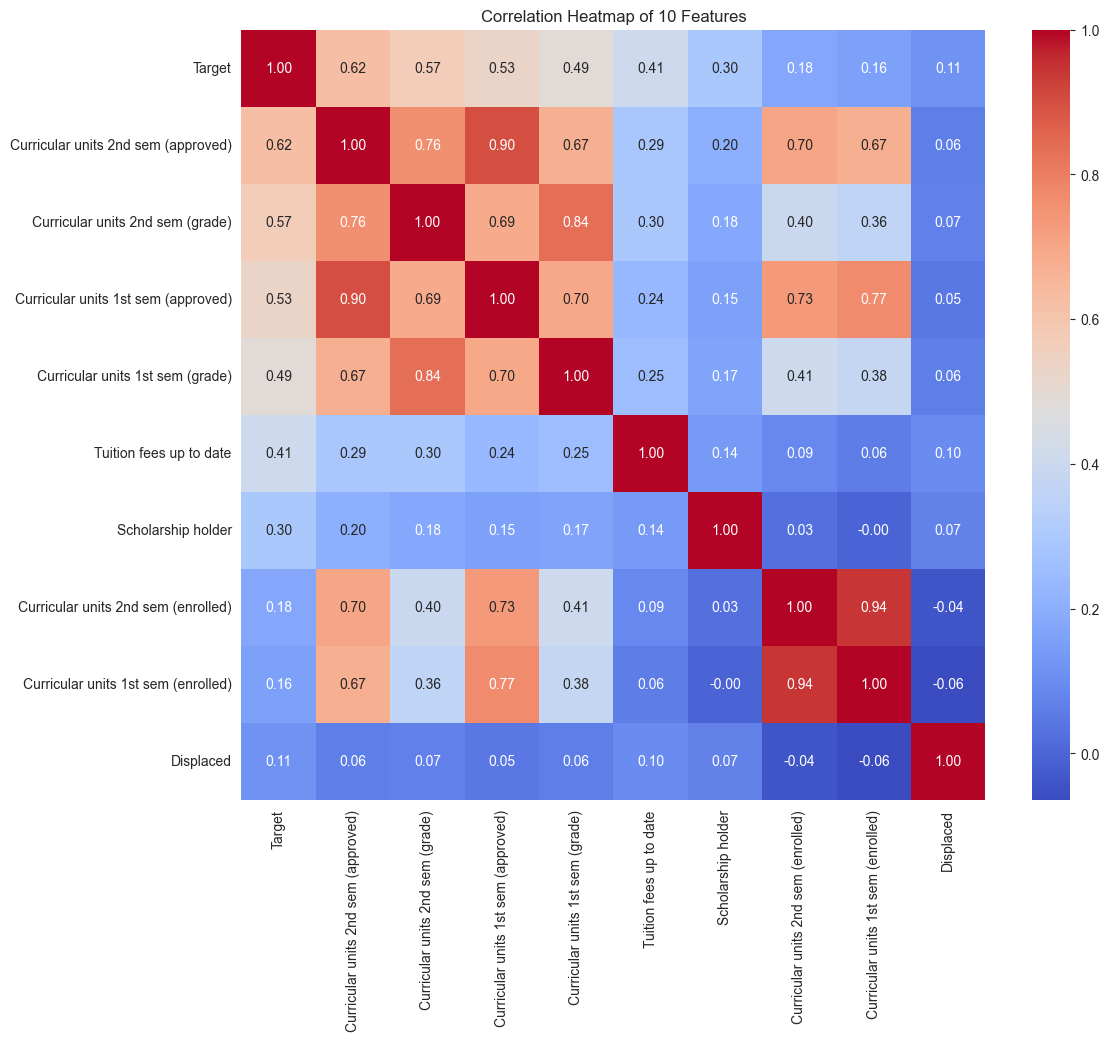

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(clstdnt_data[correlation.head(10).index].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of 10 Features')
plt.show()

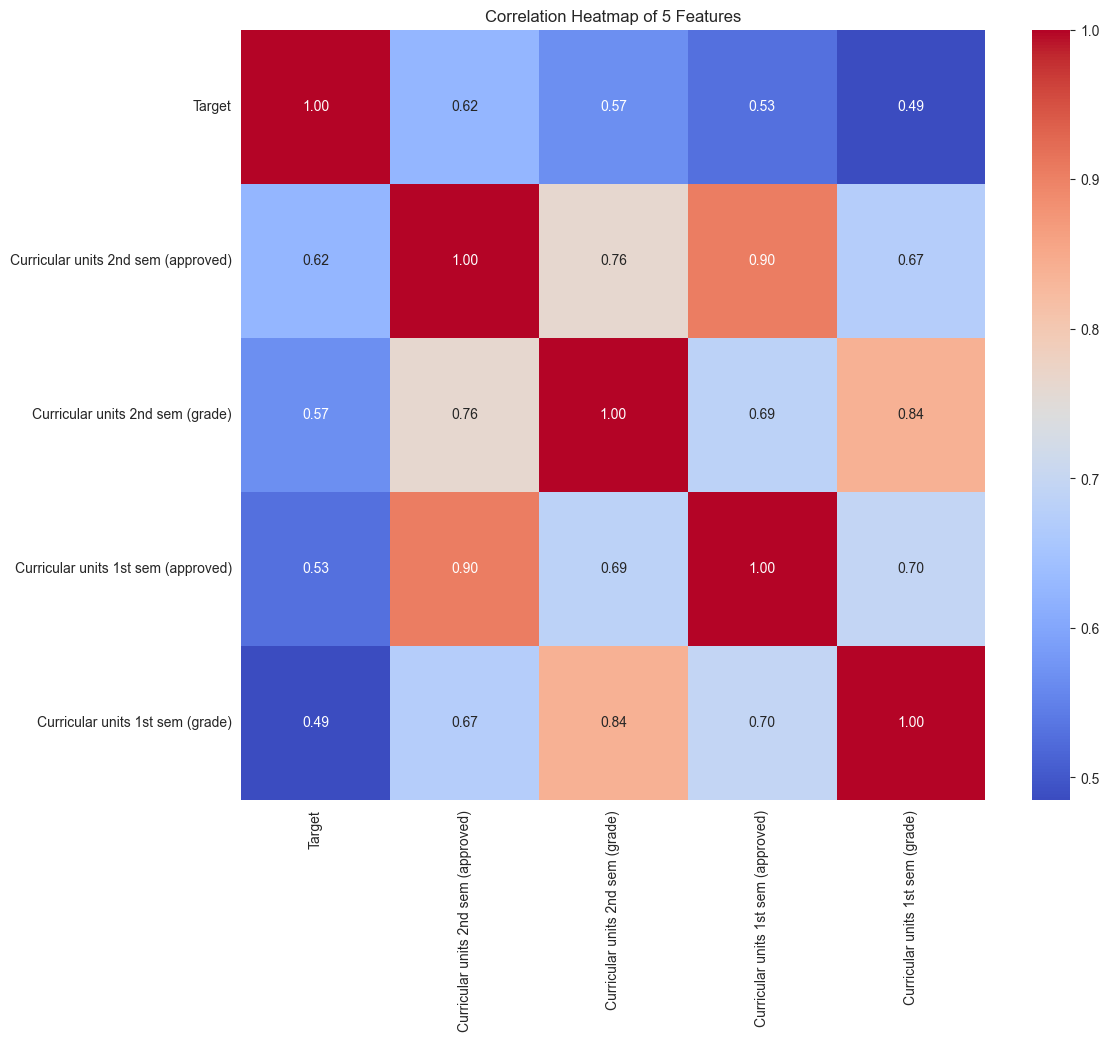

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(clstdnt_data[correlation.head(5).index].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of 5 Features')
plt.show()

<Figure size 1000x600 with 0 Axes>

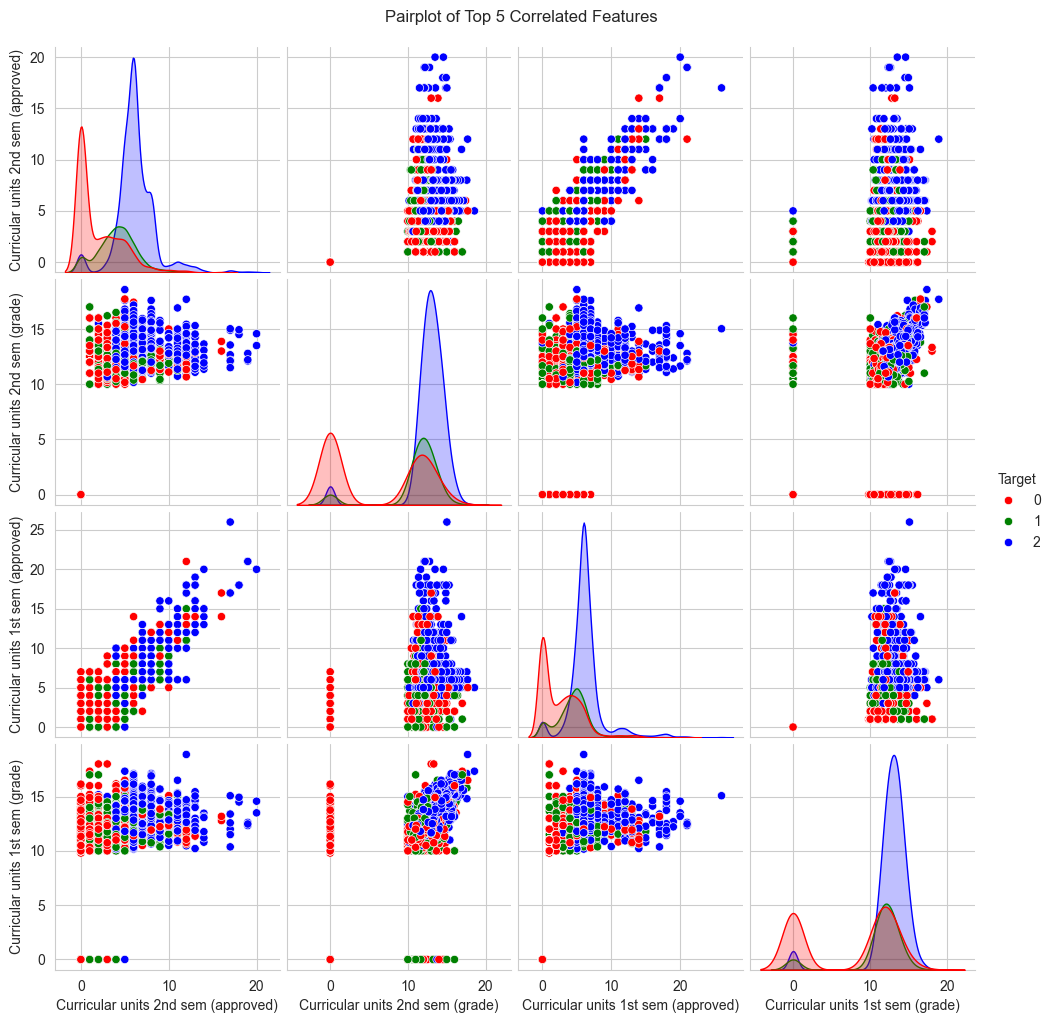

In [11]:
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
pairplot_graph = sns.pairplot(clstdnt_data[correlation.head(5).index], kind="scatter", hue='Target', palette=["red", "green", "blue"])
pairplot_graph.fig.suptitle('Pairplot of Top 5 Correlated Features', y=1.02)
plt.show()